# Predicting Insurance Costs

For this guided project, we'll be looking at the [Medical Cost Data Set](https://www.kaggle.com/datasets/mirichoi0218/insurance?resource=download) from Kaggle. This dataset contains information on individual medical insurance bills. Each bill is associated with some demographic and personal characteristics of the person who received it.

For our regression problem, we're interested in how these different characteristics relate to **the total medical cost.**


In [1]:
# import necessary module

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
%matplotlib inline

In [2]:
# Read the dataset

insurance = pd.read_csv('../../dataset/insurance.csv')
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Exploring The Dataset

In [3]:
# familarize with dataset
print(insurance.shape)
print(insurance.info())
print(insurance.isna().sum())

(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [4]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


We have `1339` rows in the dataset and 7 feature column of which three are categorical(i.e sex, smoker, and region).
- Smoker column can be converted into numerical as there are one two category Yes and NO. We can replace Yes with 1 and No with 0.
- There are no null value in the dataset

Let's see the correlation of different column with the outcome.

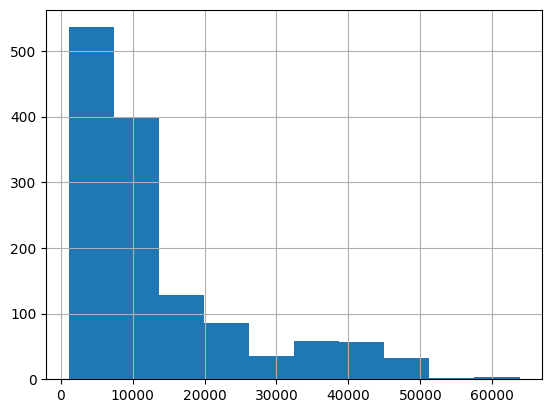

In [5]:
# check the distribution of charges
insurance['charges'].hist(bins = 10)
plt.show()

Most the charges are within 20000$ `16639.91 dollar` is the `75` percentile of the charges. The plot is right skewed which shows positive correlation.
This show most of the people have cheaper insurance compared to expensive one.

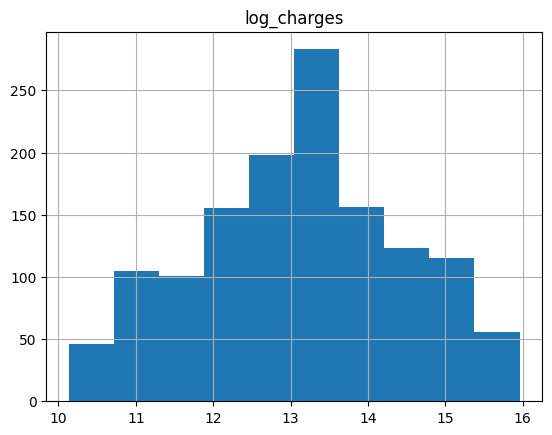

In [6]:
#transforming charges using a base-2 log 
insurance["log_charges"] = np.log2(insurance["charges"])

# visualizing transformed charges shape
insurance.hist("log_charges")
plt.show()

After log transformation we are getting a normal distribution.

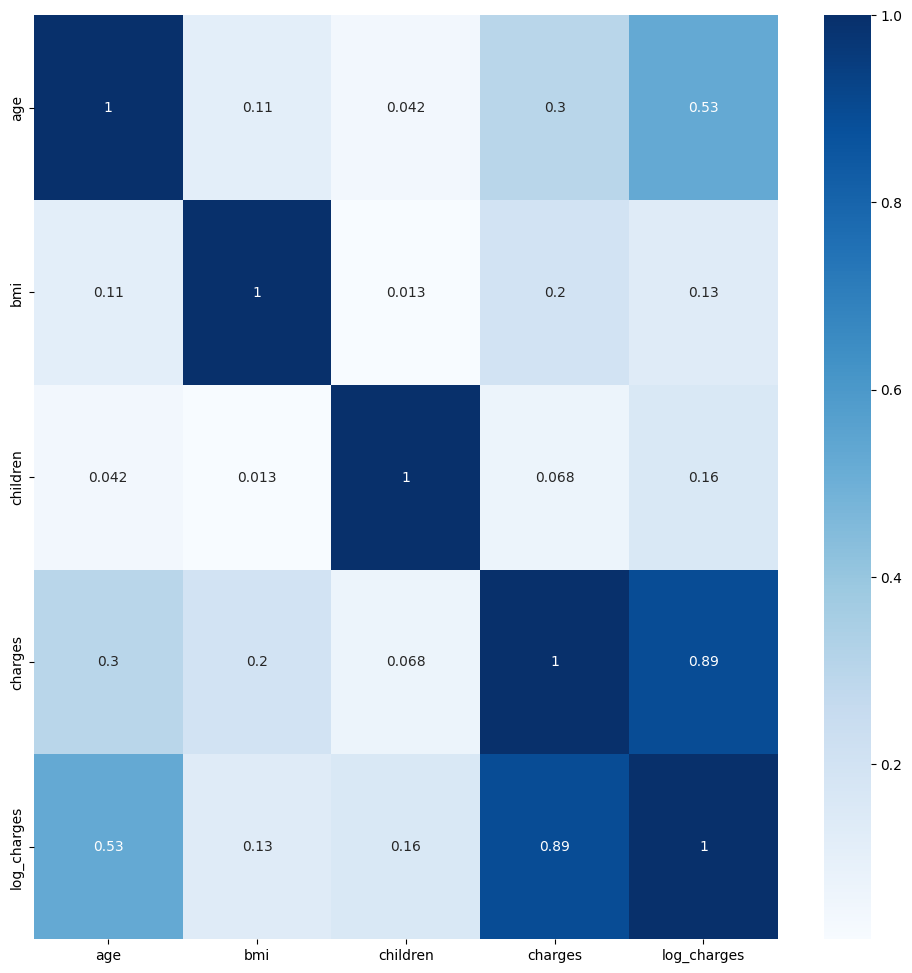

In [7]:
# Visualize the correlation between columns.
fig = plt.figure(figsize = (12, 12))
sns.heatmap(insurance.corr(numeric_only = True), annot = True, cmap = 'Blues')
plt.show()

- `Age` and `charges` have  correlation of `0.3` with `0.53` in log transform charges. 
- `BMI` and `charges` correlation of `0.2` with 0.13 in log_charges.

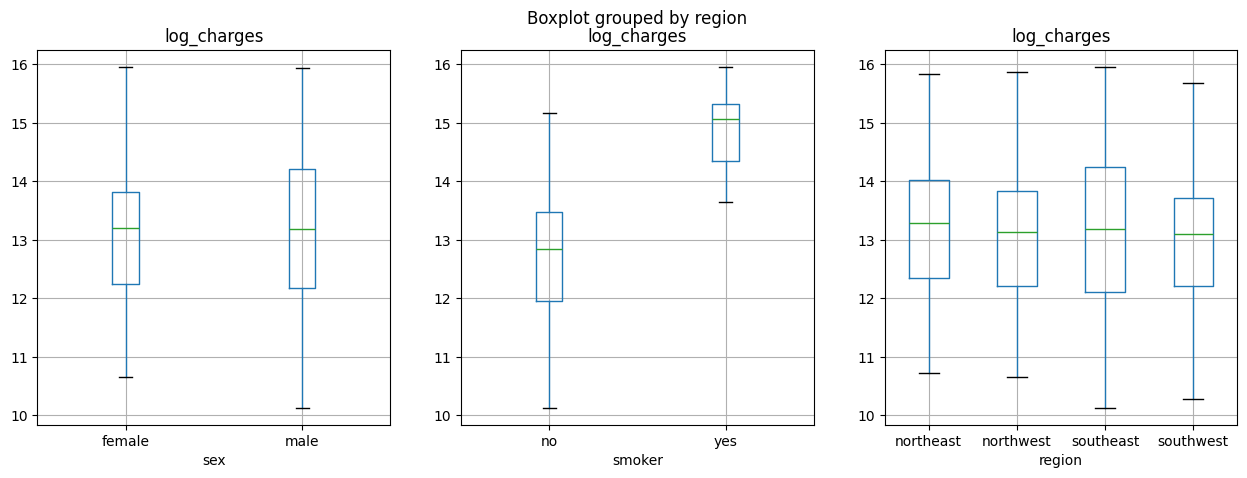

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

insurance.boxplot(column=["log_charges"], by="sex", ax=axs[0])
insurance.boxplot(column=["log_charges"], by="smoker", ax=axs[1])
insurance.boxplot(column=["log_charges"], by="region", ax=axs[2])

plt.show()

- male have wider distribution of log_charges compared to female.
- smoker have higher insurance charges compared to non-smoker
- southeast region have more wider distribution of charges compared to other region.

### Determining the features:
Based on the univariate relationships shown above, `age`, `bmi`, and `smoker`are positively associated with higher charges. We'll include these predictors in our final model.

## Dividing The Data

we need to divide the insurance dataset into two portions:

- A training set that will be used to estimate the regression coefficients
- A test set that will be used to assess the predictive ability of the model

In [9]:
# converting the smoker column
insurance['smoker'] = insurance['smoker'].apply(lambda x: 1 if x == 'yes' else 0)
cols_to_keep = ['age', 'bmi', 'smoker']

X = insurance[cols_to_keep]
y = insurance['log_charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Build The Model

we're ready to build our predictive linear model.

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)
print(f'Intercept:{model.intercept_}')
print(f'Model coefficient:{model.coef_}')
y_pred = model.predict(X_train)

r2_score = r2_score(y_train, y_pred)
mse = np.exp2(mean_squared_error(y_train, y_pred))
print(f'MSE error orignal scale:{mse}')
print(f'R2_score:{r2_score}')

Intercept:10.218903343382255
Model coefficient:[0.05025334 0.01608828 2.23414187]
MSE error orignal scale:1.370173330933378
R2_score:0.737066139753993


In [11]:
train_mse = mean_squared_error(y_train, y_pred)
train_mse

0.45435840987226683

The training MSE for the model is 0.454 and is 1.37 on the original scale. The `r2` indicates that the model can explain 73.% of the variation in the log-insurance charges. These preliminary results are promising, but we must remember that these are optimistic values.

## Residual Diagnostics

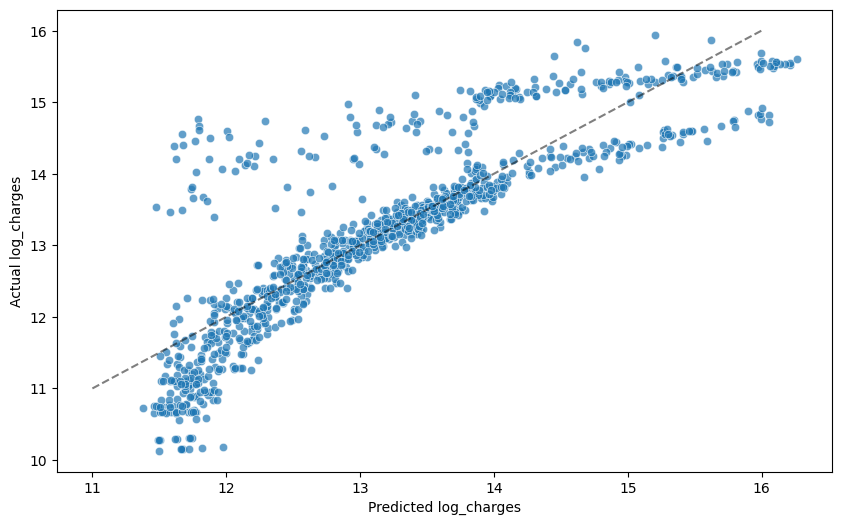

In [19]:
# Create a DataFrame with predictions, actual values, and residuals for easier plotting
plot_df = pd.DataFrame({
    'predictions': y_pred,
    'actual': y_train,
    'smoker': X_train['smoker'],
    'age': X_train['age'],
    'bmi': X_train['bmi'],
    'residuals': y_train - y_pred,
})

# Quick visual check of actual values versus predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x='predictions', y='actual', 
                data=plot_df, alpha=0.7)
# Create a reference line
plt.plot([11, 16], [11, 16], 'k--', alpha=0.5)


plt.xlabel('Predicted log_charges')
plt.ylabel('Actual log_charges')

plt.show()

Our reference line compared to our scatter plot show that our model is not performing well on  predicting linearly.

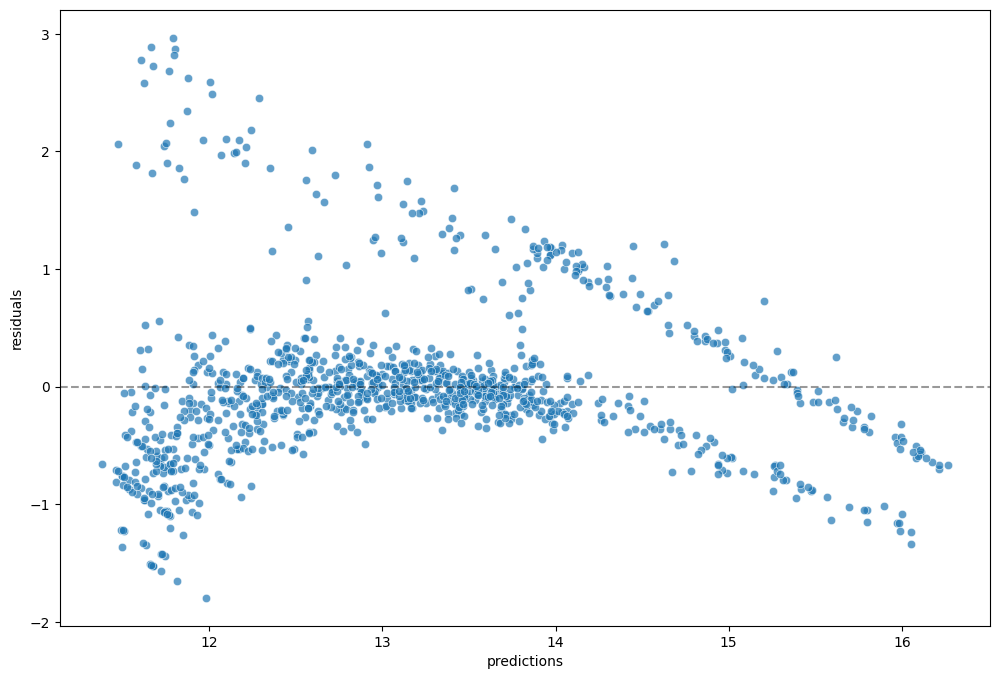

In [25]:
plt.figure(figsize = (12,8))
sns.scatterplot(x = 'predictions', y = 'residuals', data = plot_df, alpha = 0.7)
plt.axhline(y = 0, linestyle = '--', alpha = 0.4, color = 'k' )
plt.show()

The residuals suggest some violations to the assumptions of linear regression. As predicted values get larger, the residuals trend downward. We expect an even band, centered around zero. This does not necessarily make the model predictions unusable, but it puts into question the linear regression assumptions.

## Interpreting The Model


In [27]:
cdf = pd.DataFrame(model.coef_, X.columns, columns=['Coef'])
print(cdf)

            Coef
age     0.050253
bmi     0.016088
smoker  2.234142


In [29]:
model.intercept_

np.float64(10.218903343382255)

**Translating this into a "concept"**  
Note that the formula below is just to exemplify what the linear regression equation would look like:

$$charges = 0.05 \times age + 0.016 \times bmi + 2.232 \times smoker + 10.2$$

- A year increase in `age` in the subject is associated with a 0.05 increase in the log charges, holding smoking status and bmi constant.
- A unit increase in the subject `bmi` is associated with a 0.016 increase in the log charges, holding smoking status and age constant.
- A `smoker` is associated with a 2.23 increase in the log charges, holding age and bmi constant.

Note: we are not concerned about if these changes are statistically significant, so we don't know if these associations are truly non-zero. Our primary goal is prediction.

##  Final Model Evaluation

Fit the model to the test dataset and calculate the test prediction error.

In [30]:
# Test mse in log scale
test_prediction = model.predict(X_test)
mse_test = mean_squared_error(y_test, test_prediction)
print(f'Mean Squared Error:{mse_test}')

Mean Squared Error:0.4295064942032841


In [31]:
# Test mse in original scale
np.exp2(mean_squared_error(y_test, test_prediction))

np.float64(1.346772804590541)

## Conclusion

The test MSE was about 0.429, while the training MSE was about 0.454. In this case, the two errors match up pretty well, so we can conclude that the model is not overfit. The residuals suggest that the model is predicting much lower costs for subjects who were actually charged much higher. Therefore the model struggles with these higher costs. As a whole, the model predictions are too conservative.

We might improve the model by including more complex terms in the regression, such as interactions or quadratic terms.